In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load clean data
df = pd.read_csv('upr_model_ready.csv')

feature_cols = ['Charging_Time', 'Reflux_Time', 'Reaction_Time', 'Reaction2_Time',
                'Cooling_Time', 'Cooling2_Time', 'Vacuum_Time', 'Dropping_Time',
                'Charging_1200_Time', '9200_Addition_With_Reflux_Time']

target = 'ActualYield Loss/(Gain)'

print("Data loaded. Shape:", df.shape)
print("Features:", len(feature_cols))
print("Target stats:")
print(df[target].describe().round(3))

Data loaded. Shape: (615, 147)
Features: 10
Target stats:
count    615.000
mean       0.545
std        0.892
min       -9.800
25%        0.100
50%        0.600
75%        0.900
max        4.700
Name: ActualYield Loss/(Gain), dtype: float64


In [2]:
# Remove extreme outliers — beyond 3 standard deviations
mean = df[target].mean()
std = df[target].std()
lower = mean - 3*std
upper = mean + 3*std

print(f"Keeping yield loss between {lower:.2f} and {upper:.2f}")

df_model = df[(df[target] >= lower) & (df[target] <= upper)].copy()
print(f"Rows after outlier removal: {len(df_model)}")
print(f"Removed: {len(df) - len(df_model)} batches")

# Prepare X and y
X = df_model[feature_cols]
y = df_model[target]

# Train test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTraining set: {len(X_train)} batches")
print(f"Test set: {len(X_test)} batches")

Keeping yield loss between -2.13 and 3.22
Rows after outlier removal: 609
Removed: 6 batches

Training set: 487 batches
Test set: 122 batches


Mean Absolute Error: 0.437%
R² Score: 0.260


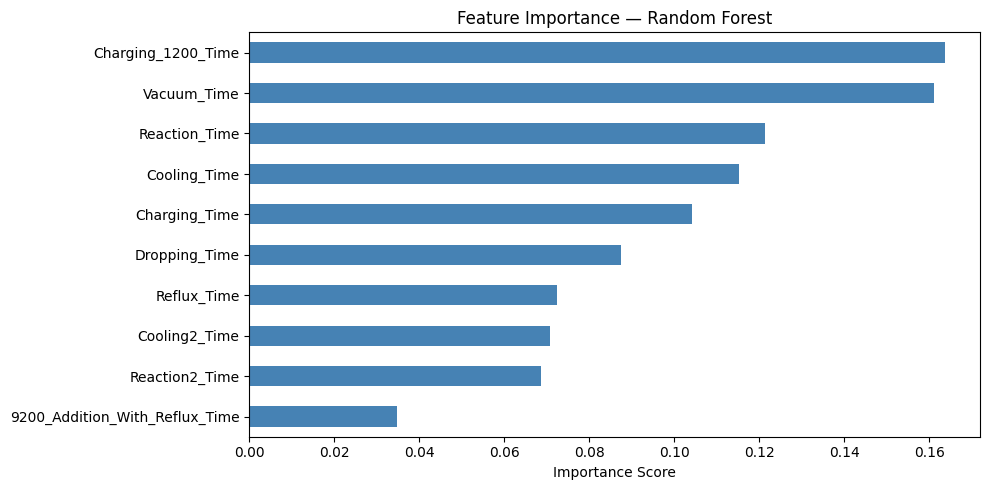


Feature importances:
Charging_1200_Time                0.164
Vacuum_Time                       0.161
Reaction_Time                     0.121
Cooling_Time                      0.115
Charging_Time                     0.104
Dropping_Time                     0.087
Reflux_Time                       0.073
Cooling2_Time                     0.071
Reaction2_Time                    0.069
9200_Addition_With_Reflux_Time    0.035
dtype: float64


In [3]:
# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.3f}%")
print(f"R² Score: {r2:.3f}")

# Feature importance
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 5))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nFeature importances:")
print(importances.sort_values(ascending=False).round(3))

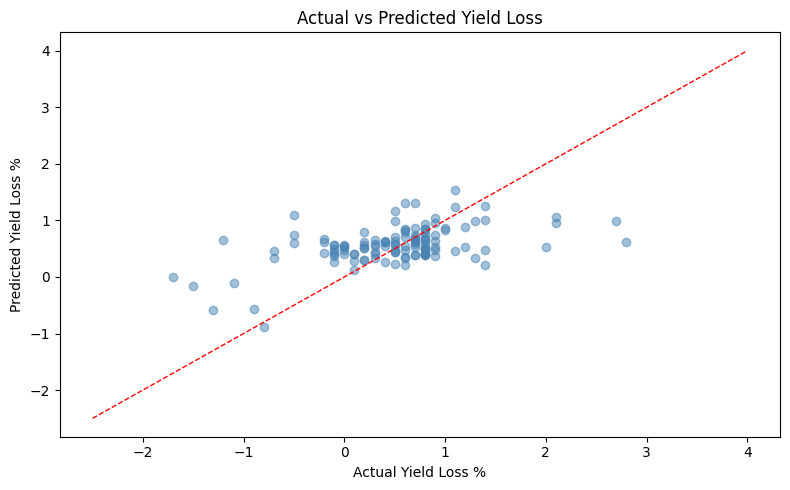

In [4]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([-2.5, 4], [-2.5, 4], 'r--', linewidth=1)
plt.xlabel('Actual Yield Loss %')
plt.ylabel('Predicted Yield Loss %')
plt.title('Actual vs Predicted Yield Loss')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150)
plt.show()

## Model Results

Random Forest Regressor trained on 10 step-level downtime features.

- MAE: 0.437% — predictions within ~0.44 percentage points on average
- R²: 0.26 — model explains 26% of yield loss variance

R² is moderate, expected for a multi-grade dataset where grade chemistry 
accounts for unexplained variance. Model is most accurate in the 0–1% 
yield loss range where 75% of batches fall. Negative yield loss (gain) 
batches are underrepresented and predicted less reliably.

Top predictors by feature importance: Charging_1200_Time, Vacuum_Time, 
Reaction_Time — consistent with domain knowledge that charging completeness 
and reaction endpoint control are critical for UPR yield.